StatementMeta(yudhaesparkpool, 2, 72, Finished, Available, Finished, False)

 VISUALISASI DISTRIBUSI SKOR POTENSI - VERSI LENGKAP


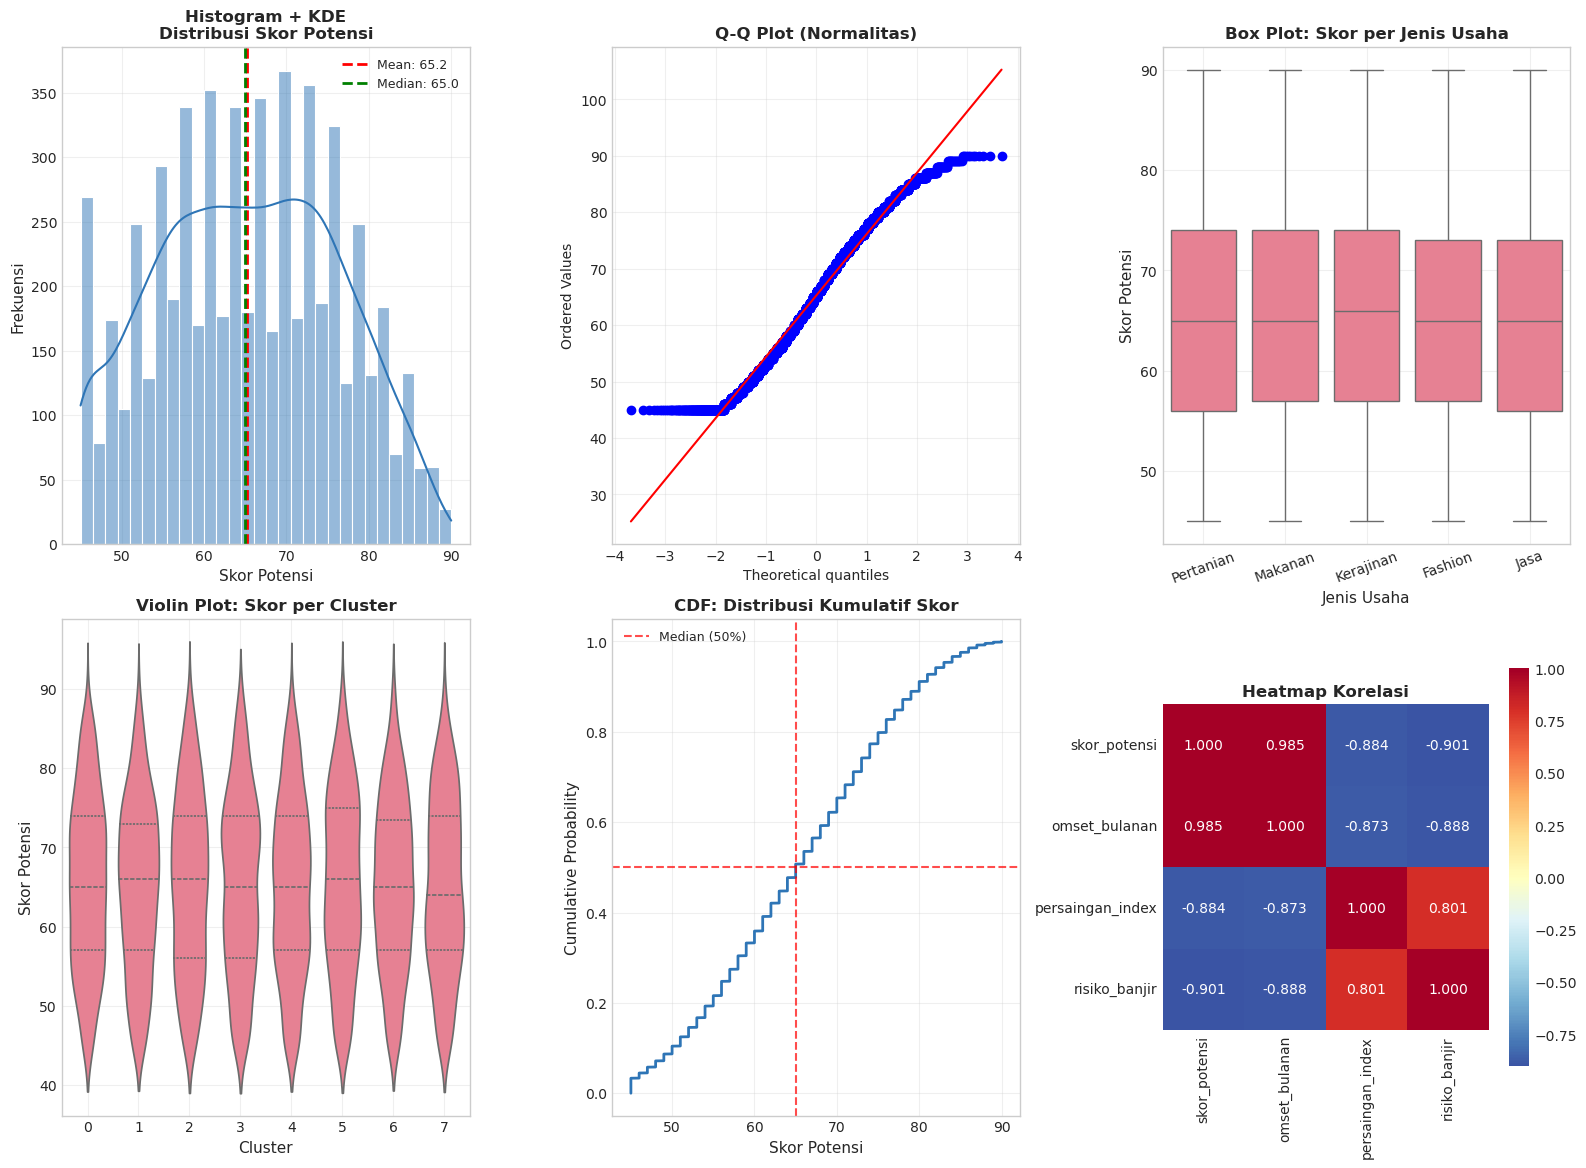


 STATISTIK TAMBAHAN

📊 SKEWNESS: 0.0156
📊 KURTOSIS: -0.8745
📊 COEFFICIENT OF VARIATION: 16.82%

>>> PERCENTILES:
   P10: 50.0
   P25: 57.0
   P50: 65.0
   P75: 74.0
   P90: 80.0

>>> OUTLIERS (IQR Method):
   Jumlah outliers: 0 (0.00%)
   Lower bound: 31.5 | Upper bound: 99.5


In [65]:
# === VISUALISASI DISTRIBUSI SKOR (VERSI LENGKAP) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

# Load data
df = spark.read.parquet("/lakehouse/default/Files/umkm_v3_final")
pdf = df.select("skor_potensi", "jenis_usaha", "cluster", "omset_bulanan", 
                "persaingan_index", "risiko_banjir").toPandas()

print("="*70)
print(" VISUALISASI DISTRIBUSI SKOR POTENSI - VERSI LENGKAP")
print("="*70)

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

fig = plt.figure(figsize=(16, 12))

# 1. HISTOGRAM + KDE
ax1 = plt.subplot(2, 3, 1)
sns.histplot(pdf['skor_potensi'], bins=30, kde=True, color='#2E75B6', edgecolor='white', ax=ax1)
ax1.axvline(pdf['skor_potensi'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {pdf["skor_potensi"].mean():.1f}')
ax1.axvline(pdf['skor_potensi'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {pdf["skor_potensi"].median():.1f}')
ax1.set_xlabel('Skor Potensi', fontsize=11)
ax1.set_ylabel('Frekuensi', fontsize=11)
ax1.set_title('Histogram + KDE\nDistribusi Skor Potensi', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Q-Q PLOT (Normalitas)
ax2 = plt.subplot(2, 3, 2)
stats.probplot(pdf['skor_potensi'], dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (Normalitas)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. BOX PLOT PER JENIS USAHA
ax3 = plt.subplot(2, 3, 3)
sns.boxplot(data=pdf, x='jenis_usaha', y='skor_potensi', ax=ax3)
ax3.set_xlabel('Jenis Usaha', fontsize=11)
ax3.set_ylabel('Skor Potensi', fontsize=11)
ax3.set_title('Box Plot: Skor per Jenis Usaha', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=20)
ax3.grid(True, alpha=0.3)

# 4. VIOLIN PLOT PER CLUSTER
ax4 = plt.subplot(2, 3, 4)
sns.violinplot(data=pdf, x='cluster', y='skor_potensi', ax=ax4, inner='quartile')
ax4.set_xlabel('Cluster', fontsize=11)
ax4.set_ylabel('Skor Potensi', fontsize=11)
ax4.set_title('Violin Plot: Skor per Cluster', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. CDF (Cumulative Distribution Function)
ax5 = plt.subplot(2, 3, 5)
sorted_scores = np.sort(pdf['skor_potensi'])
cdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
ax5.plot(sorted_scores, cdf, color='#2E75B6', linewidth=2)
ax5.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Median (50%)')
ax5.axvline(pdf['skor_potensi'].median(), color='red', linestyle='--', alpha=0.7)
ax5.set_xlabel('Skor Potensi', fontsize=11)
ax5.set_ylabel('Cumulative Probability', fontsize=11)
ax5.set_title('CDF: Distribusi Kumulatif Skor', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# 6. HEATMAP KORELASI
ax6 = plt.subplot(2, 3, 6)
corr_matrix = pdf[['skor_potensi', 'omset_bulanan', 'persaingan_index', 'risiko_banjir']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            square=True, fmt='.3f', ax=ax6, cbar_kws={'shrink': 0.8})
ax6.set_title('Heatmap Korelasi', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Statistik Tambahan
print("\n" + "="*70)
print(" STATISTIK TAMBAHAN")
print("="*70)

print(f"\n📊 SKEWNESS: {stats.skew(pdf['skor_potensi']):.4f}")
print(f"📊 KURTOSIS: {stats.kurtosis(pdf['skor_potensi']):.4f}")
print(f"📊 COEFFICIENT OF VARIATION: {(pdf['skor_potensi'].std() / pdf['skor_potensi'].mean()) * 100:.2f}%")

print("\n>>> PERCENTILES:")
for p in [10, 25, 50, 75, 90]:
    print(f"   P{p:2d}: {np.percentile(pdf['skor_potensi'], p):.1f}")

print("\n>>> OUTLIERS (IQR Method):")
Q1 = pdf['skor_potensi'].quantile(0.25)
Q3 = pdf['skor_potensi'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = pdf[(pdf['skor_potensi'] < lower_bound) | (pdf['skor_potensi'] > upper_bound)]
print(f"   Jumlah outliers: {len(outliers)} ({len(outliers)/len(pdf)*100:.2f}%)")
print(f"   Lower bound: {lower_bound:.1f} | Upper bound: {upper_bound:.1f}")